# Análisis Exploratorio de Datos (EDA) - Proyecto Aurelion

## Estructura del Análisis
0. Importar librerías
1. Cargar datos desde `data/interim`
2. Unificar y preprocesar datos
3. Análisis Exploratorio de Datos (EDA)
   - 3.1 Análisis univariado
   - 3.2 Análisis bivariado
   - 3.3 Correlaciones / Mapa de calor
   - 3.4 Gráficas de verificación
4. Observaciones y conclusiones

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## Paso 1: Cargar datos limpios

In [26]:
clientes = pd.read_csv('./data/interim/clientes.csv')
ventas = pd.read_csv('./data/interim/ventas.csv')
productos = pd.read_csv('./data/interim/productos.csv')
detalle_ventas = pd.read_csv('./data/interim/detalle_ventas.csv')

print("Clientes:", clientes.shape)
print("Productos:", productos.shape)
print("Ventas:", ventas.shape)
print("Detalle Ventas:", detalle_ventas.shape)

Clientes: (100, 5)
Productos: (100, 4)
Ventas: (120, 6)
Detalle Ventas: (343, 6)


## Paso 2: Unificar datasets con merge

In [4]:
df = (detalle_ventas
    .merge(ventas, on='id_venta', how='left')
    .merge(clientes, on='id_cliente', how='left')
    .merge(productos, on='id_producto', how='left'))

if 'precio_unitario_x' in df.columns:
    df['precio_unitario'] = df['precio_unitario_x']
    df.drop(['precio_unitario_x', 'precio_unitario_y'], axis=1, inplace=True)

if 'nombre_producto_x' in df.columns:
    df['nombre_producto'] = df['nombre_producto_y']  
    df.drop(['nombre_producto_x', 'nombre_producto_y'], axis=1, inplace=True)

if 'nombre_cliente_x' in df.columns:
    df['nombre_cliente'] = df['nombre_cliente_y']  
    df.drop(['nombre_cliente_x', 'nombre_cliente_y'], axis=1, inplace=True)

if 'email_x' in df.columns:
    df['email'] = df['email_y']  
    df.drop(['email_x', 'email_y'], axis=1, inplace=True)

print(f"Dataset unificado: {df.shape}")
df.sample(10, random_state=2025)

Dataset unificado: (343, 14)


,id_venta,id_producto,cantidad,importe,fecha,id_cliente,medio_pago,ciudad,fecha_alta,categoria,precio_unitario,nombre_producto,nombre_cliente,email
295,105,43,5,4435,2024-02-06,1,transferencia,Carlos Paz,2023-01-01,Alimento,887,Salsa de Tomate 500g,Mariana Lopez,mariana.lopez@mail.com
257,93,66,3,4599,2024-01-29,90,efectivo,Rio Cuarto,2023-03-31,Alimento,1533,Cerveza Negra 1L,Guadalupe Ruiz,guadalupe.ruiz@mail.com
146,52,9,4,15512,2024-05-10,5,tarjeta,Cordoba,2023-01-05,Alimento,3878,Yerba Mate Suave 1kg,Agustina Flores,agustina.flores@mail.com
50,19,38,2,3168,2024-06-11,80,efectivo,Mendiolaza,2023-03-21,Alimento,1584,Mermelada de Frutilla 400g,Gael Ruiz,gael.ruiz@mail.com
263,95,12,1,570,2024-02-25,26,qr,Alta Gracia,2023-01-26,Alimento,570,Té Negro 20 saquitos,Camila Sanchez,camila.sanchez@mail.com
58,22,24,4,5220,2024-05-08,64,transferencia,Villa Maria,2023-03-05,Alimento,1305,Galletitas Chocolate,Julian Alvarez,julian.alvarez@mail.com
172,61,19,3,9753,2024-06-01,27,efectivo,Rio Cuarto,2023-01-27,Alimento,3251,Manteca 200g,Tomas Castro,tomas.castro@mail.com
248,88,53,5,8320,2024-06-21,37,efectivo,Mendiolaza,2023-02-06,Limpieza,1664,Lavandina 1L,Martina Perez,martina.perez@mail.com
122,44,100,2,9708,2024-02-21,21,efectivo,Alta Gracia,2023-01-21,Limpieza,4854,Trapo de Piso,Elena Rodriguez,elena.rodriguez@mail.com
120,44,48,1,4462,2024-02-21,21,efectivo,Alta Gracia,2023-01-21,Alimento,4462,Porotos Negros 500g,Elena Rodriguez,elena.rodriguez@mail.com


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_venta         343 non-null    int64 
 1   id_producto      343 non-null    int64 
 2   cantidad         343 non-null    int64 
 3   importe          343 non-null    int64 
 4   fecha            343 non-null    object
 5   id_cliente       343 non-null    int64 
 6   medio_pago       343 non-null    object
 7   ciudad           343 non-null    object
 8   fecha_alta       343 non-null    object
 9   categoria        343 non-null    object
 10  precio_unitario  343 non-null    int64 
 11  nombre_producto  343 non-null    object
 12  nombre_cliente   343 non-null    object
 13  email            343 non-null    object
dtypes: int64(6), object(8)
memory usage: 37.6+ KB


### Observaciones iniciales:

Se resolvieron las columnas duplicadas del merge:
- `precio_unitario`: se mantiene el de detalle_ventas (precio transaccional)
- `nombre_producto`: se mantiene el del catálogo de productos

Próximos pasos:
- Crear columnas temporales: `mes`, `anio`, `dia_semana` a partir de `fecha`
- Analizar estadísticas descriptivas

In [6]:
# Verificar estadísticas de columnas numéricas
num_cols = ['precio_unitario', 'cantidad', 'importe']
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
precio_unitario,343.0,2654.495627,1308.694720,272.0,1618.5,2512.0,3876.0,4982.0
cantidad,343.0,2.962099,1.366375,1.0,2.0,3.0,4.0,5.0
importe,343.0,7730.078717,5265.543077,272.0,3489.0,6702.0,10231.5,24865.0


### Observaciones estadísticas:
- Verificar posibles outliers en `importe` (comparar max vs percentil 75)
- Analizar distribución de `cantidad` y `precio_unitario`

In [7]:
# Preprocesamiento: agregar columnas temporales y limpiar duplicados
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month_name()
df['dia_semana'] = df['fecha'].dt.day_name()

print("Columnas agregadas: anio, mes, dia_semana")
print(f"Rango de fechas: {df['fecha'].min()} a {df['fecha'].max()}")

Columnas agregadas: anio, mes, dia_semana
Rango de fechas: 2024-01-02 00:00:00 a 2024-06-28 00:00:00


In [38]:
df.head()

,id_venta,id_producto,cantidad,importe,fecha,id_cliente,medio_pago,ciudad,fecha_alta,categoria,precio_unitario,nombre_producto,nombre_cliente,email,anio,mes,dia_semana
0,1,90,1,2902,2024-06-19,62,tarjeta,Carlos Paz,2023-03-03,Limpieza,2902,Toallas Húmedas x50,Guadalupe Romero,guadalupe.romero@mail.com,2024,June,Wednesday
1,2,82,5,11970,2024-03-17,49,qr,Rio Cuarto,2023-02-18,Alimento,2394,Aceitunas Negras 200g,Olivia Gomez,olivia.gomez@mail.com,2024,March,Sunday
2,2,39,5,2345,2024-03-17,49,qr,Rio Cuarto,2023-02-18,Alimento,469,Helado Vainilla 1L,Olivia Gomez,olivia.gomez@mail.com,2024,March,Sunday
3,2,70,2,8122,2024-03-17,49,qr,Rio Cuarto,2023-02-18,Alimento,4061,Fernet 750ml,Olivia Gomez,olivia.gomez@mail.com,2024,March,Sunday
4,2,22,1,2069,2024-03-17,49,qr,Rio Cuarto,2023-02-18,Alimento,2069,Medialunas de Manteca,Olivia Gomez,olivia.gomez@mail.com,2024,March,Sunday


## Paso 3: Análisis Exploratorio de Datos (EDA)

### 3.1 Análisis Univariado
Distribución de variables individuales

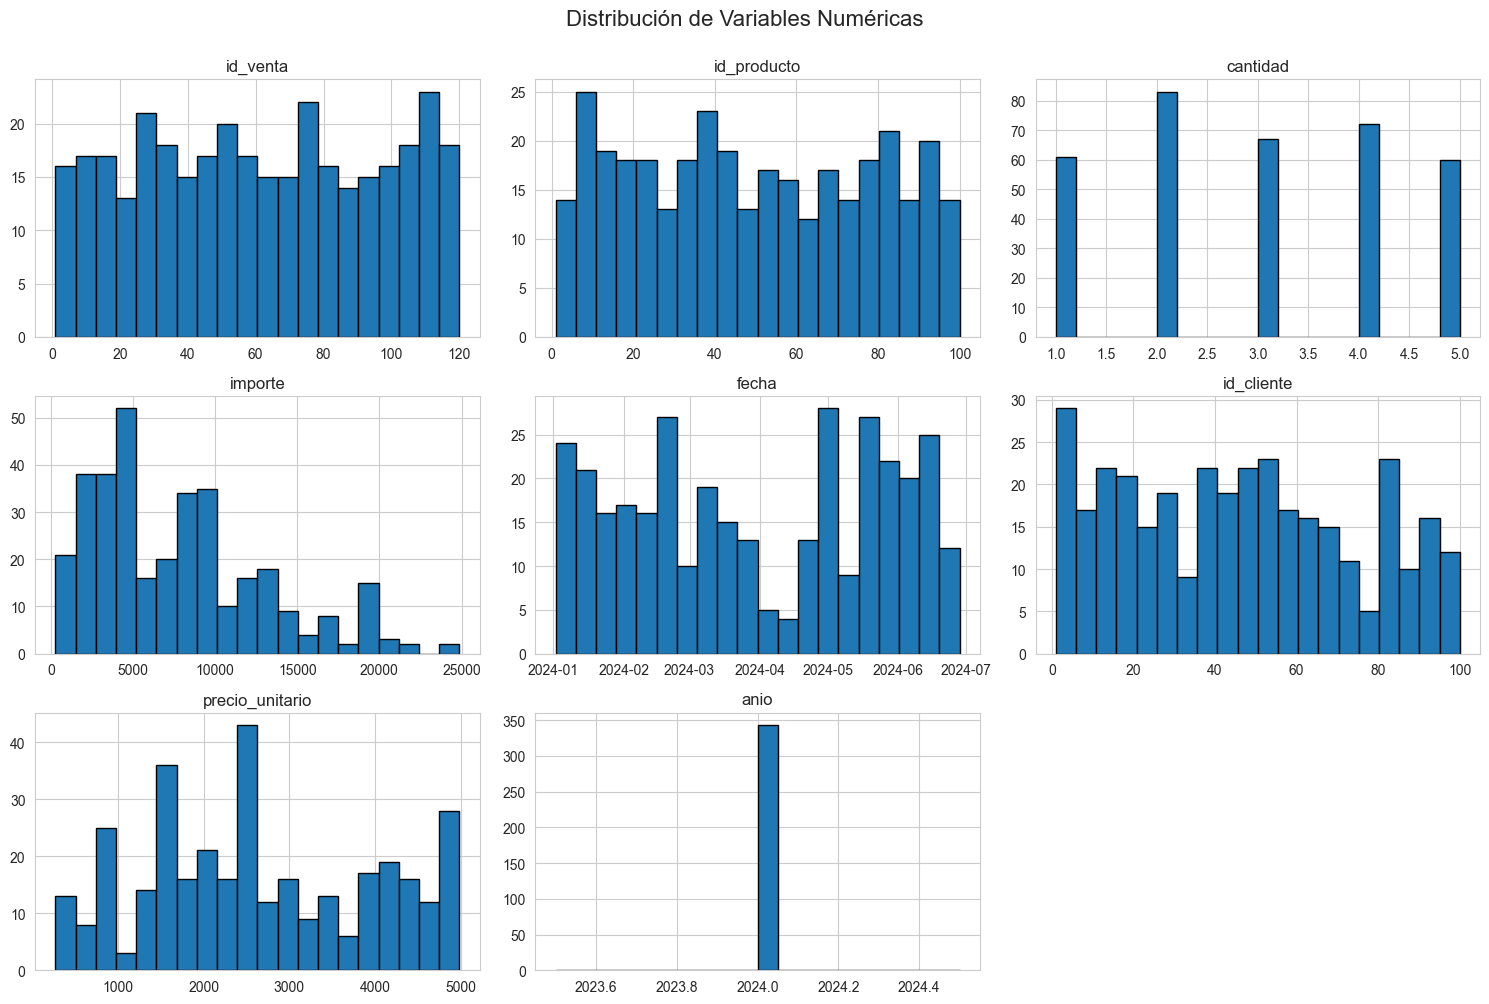

In [8]:
# Histogramas de todas las variables numéricas
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

### Observaciones univariadas:
- Verificar outliers en `importe` (cola derecha de la distribución)
- Analizar asimetría en las distribuciones

### 3.2 Análisis Bivariado
Relaciones entre pares de variables

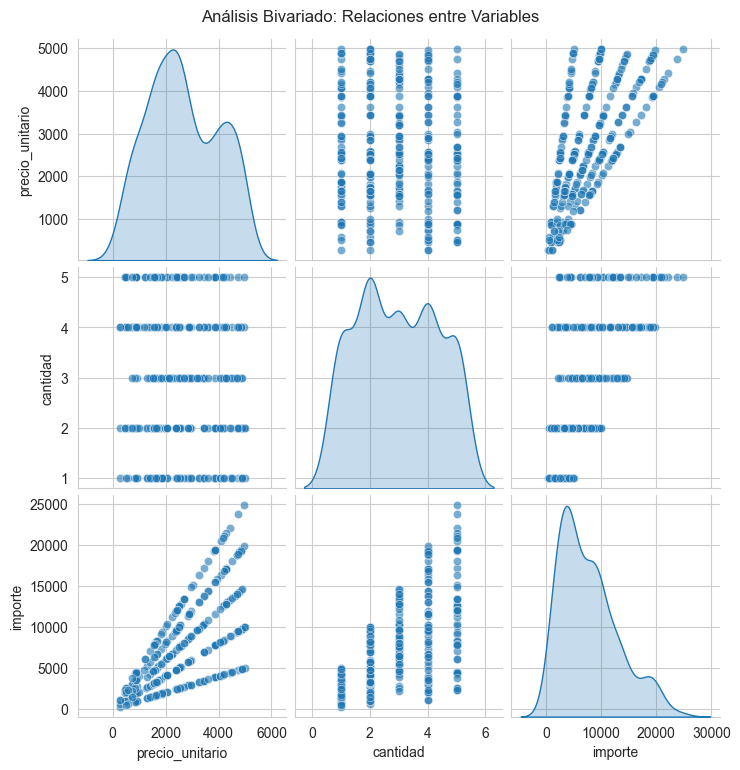

In [9]:
# Pairplot: relaciones entre variables numéricas clave
num_cols = ['precio_unitario', 'cantidad', 'importe']
sns.pairplot(data=df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Análisis Bivariado: Relaciones entre Variables', y=1.02)
plt.show()

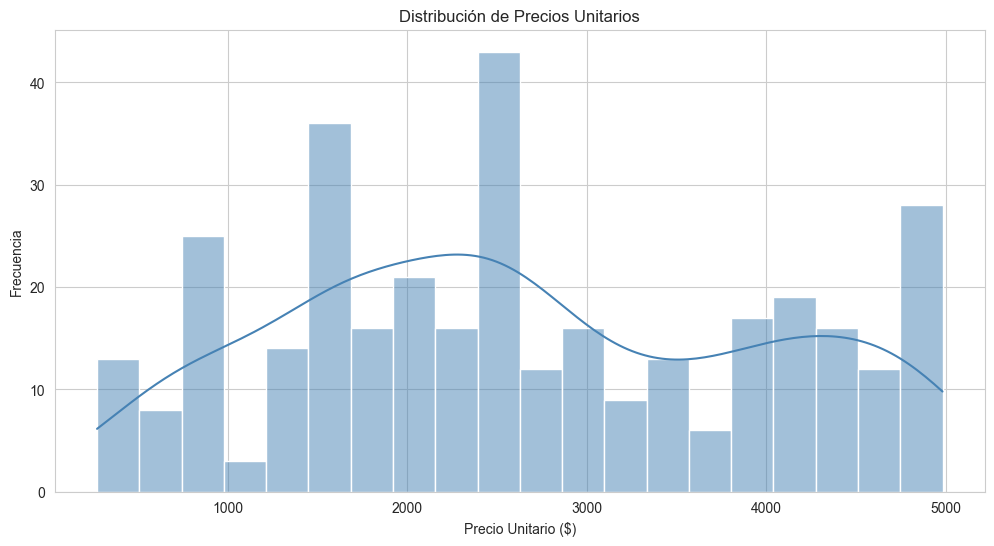

In [10]:
# Distribución de precios unitarios
sns.histplot(df['precio_unitario'], bins=20, kde=True, color='steelblue')
plt.title('Distribución de Precios Unitarios')
plt.xlabel('Precio Unitario ($)')
plt.ylabel('Frecuencia')
plt.show()

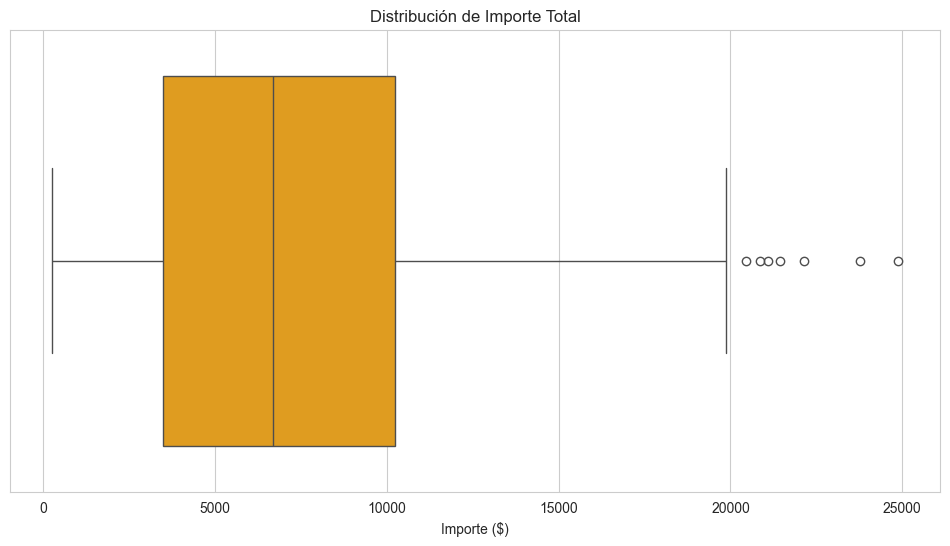

In [11]:
# Boxplot de importe
sns.boxplot(x=df['importe'], color='orange')
plt.title('Distribución de Importe Total')
plt.xlabel('Importe ($)')
plt.show()

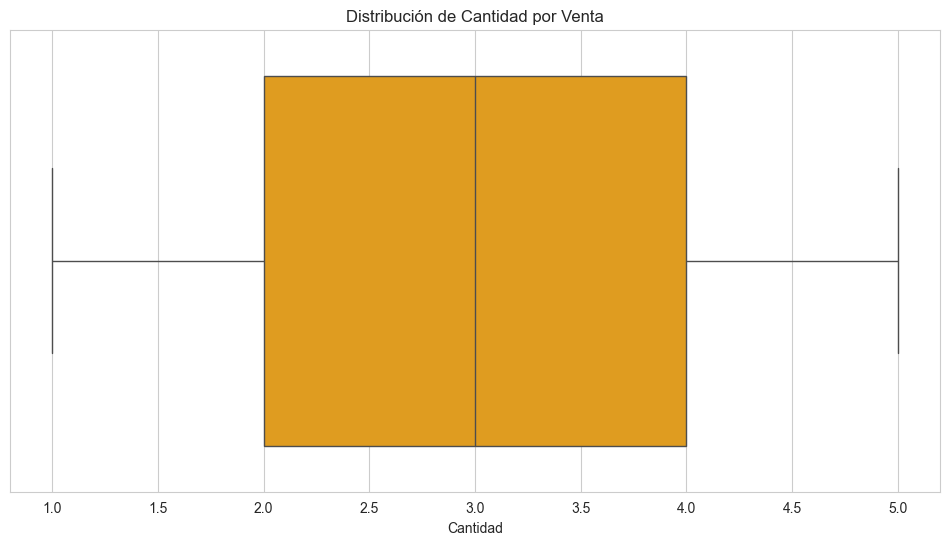

In [12]:
# Boxplot de cantidad
sns.boxplot(x=df['cantidad'], color='orange')
plt.title('Distribución de Cantidad por Venta')
plt.xlabel('Cantidad')
plt.show()

### Observaciones:
- Los boxplots muestran la presencia de outliers en cantidad e importe
- Se puede considerar mantener outliers (son ventas válidas) o analizar por separado

C:\Users\mauro\AppData\Local\Temp\ipykernel_8920\2762755404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='medio_pago', data=df, palette='Set2')


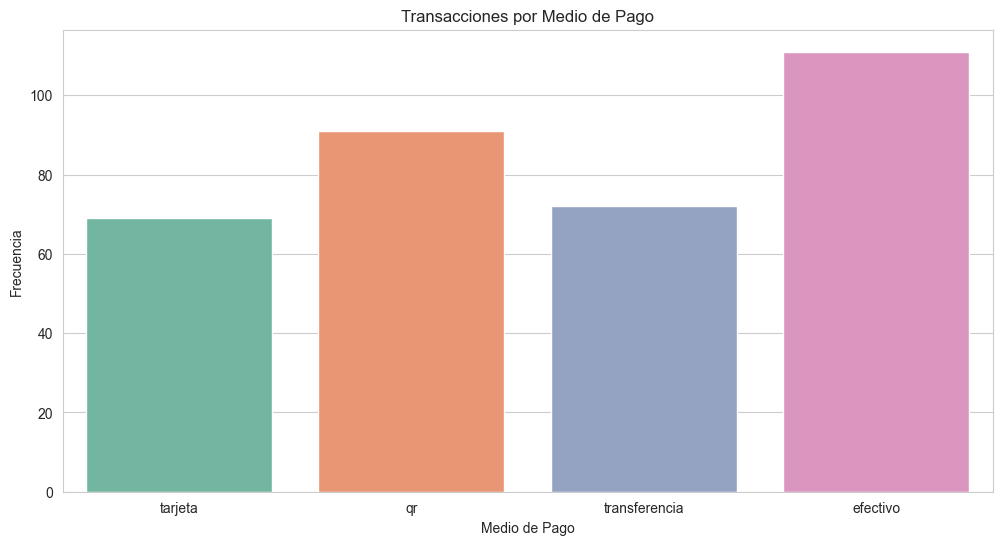

In [13]:
# Distribución por medio de pago
sns.countplot(x='medio_pago', data=df, palette='Set2')
plt.title('Transacciones por Medio de Pago')
plt.xlabel('Medio de Pago')
plt.ylabel('Frecuencia')
plt.show()

C:\Users\mauro\AppData\Local\Temp\ipykernel_8920\2188471800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='ciudad', data=df, order=df['ciudad'].value_counts().index, palette='viridis')


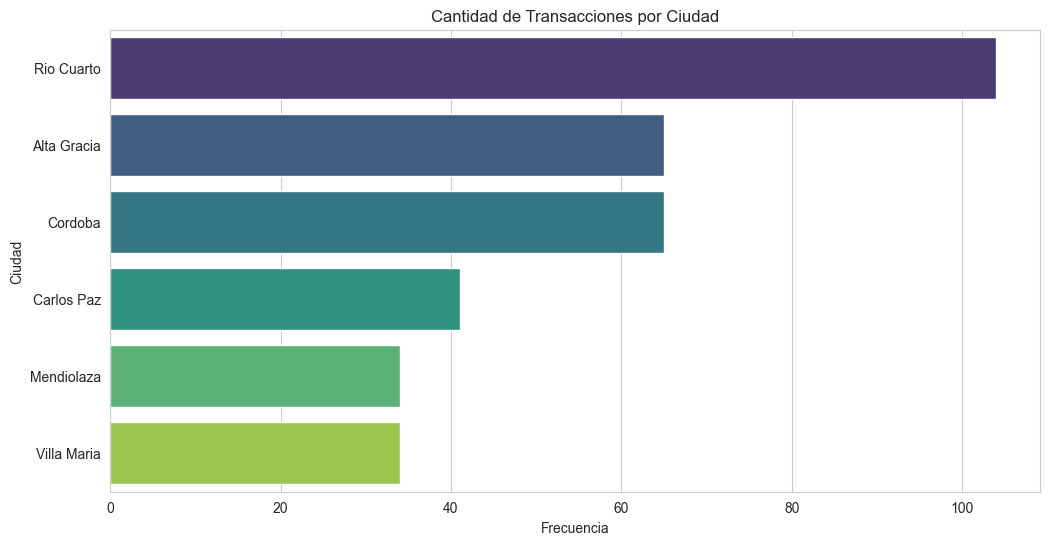

In [14]:
# Análisis de ciudades con mayor volumen de ventas
sns.countplot(y='ciudad', data=df, order=df['ciudad'].value_counts().index, palette='viridis')
plt.title('Cantidad de Transacciones por Ciudad')
plt.xlabel('Frecuencia')
plt.ylabel('Ciudad')
plt.show()

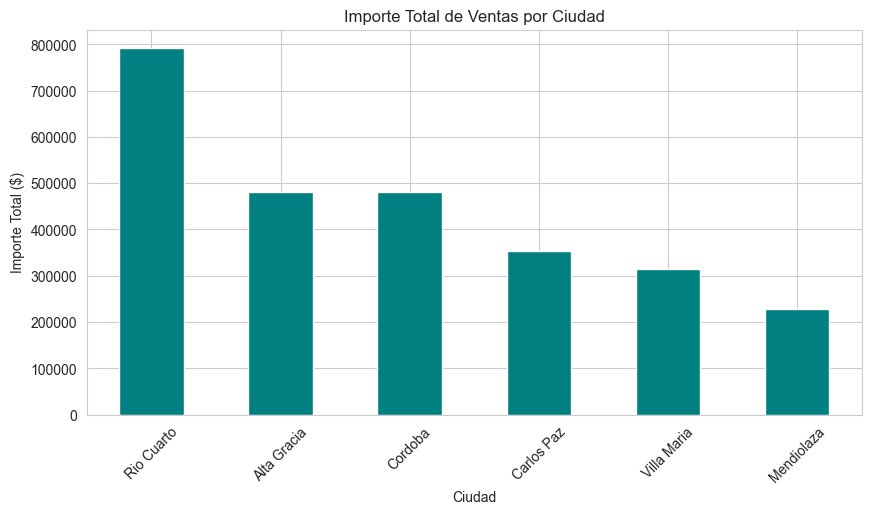

In [15]:
# Ventas totales por ciudad
ventas_ciudad = df.groupby('ciudad')['importe'].sum().sort_values(ascending=False)
ventas_ciudad.plot.bar(color='teal', figsize=(10, 5))
plt.title('Importe Total de Ventas por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Importe Total ($)')
plt.xticks(rotation=45)
plt.show()

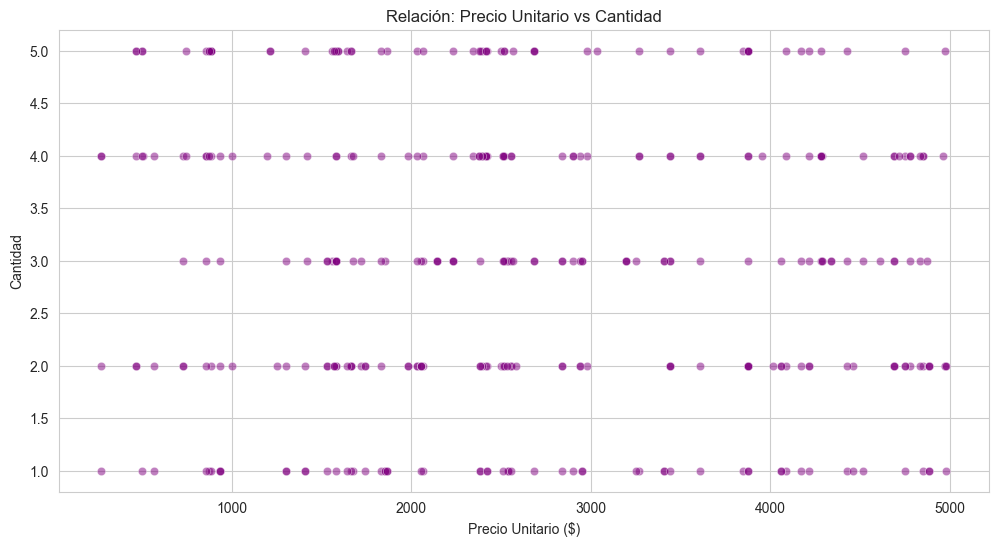

In [16]:
# Relación entre precio y cantidad
sns.scatterplot(x='precio_unitario', y='cantidad', data=df, alpha=0.5, color='purple')
plt.title('Relación: Precio Unitario vs Cantidad')
plt.xlabel('Precio Unitario ($)')
plt.ylabel('Cantidad')
plt.show()

C:\Users\mauro\AppData\Local\Temp\ipykernel_8920\1045665757.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='medio_pago', y='importe', data=df, estimator=sum, ci=None, palette='pastel')
C:\Users\mauro\AppData\Local\Temp\ipykernel_8920\1045665757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='medio_pago', y='importe', data=df, estimator=sum, ci=None, palette='pastel')


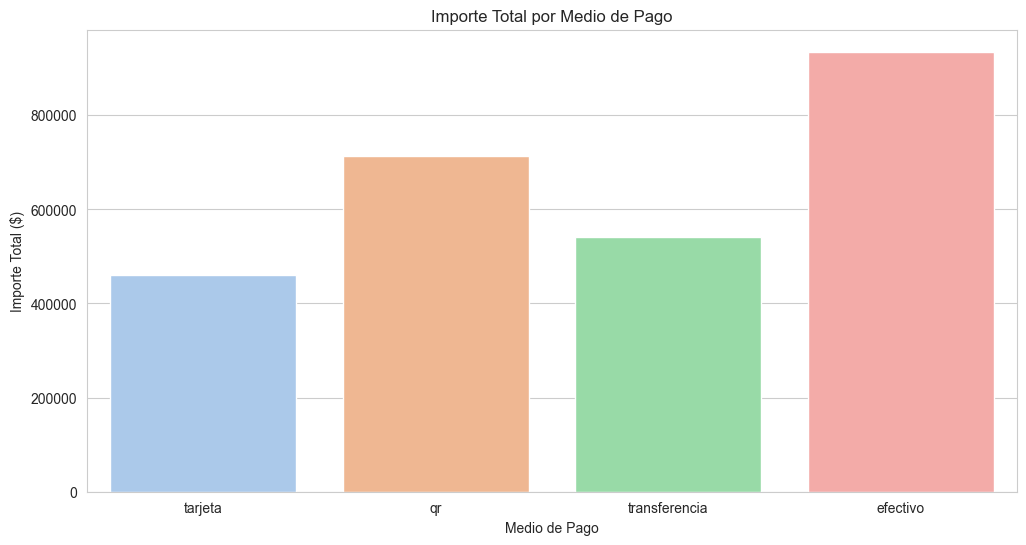

In [17]:
# Importe promedio por medio de pago
sns.barplot(x='medio_pago', y='importe', data=df, estimator=sum, ci=None, palette='pastel')
plt.title('Importe Total por Medio de Pago')
plt.xlabel('Medio de Pago')
plt.ylabel('Importe Total ($)')
plt.show()

In [18]:
# Matriz de correlación
cor = df[['precio_unitario', 'cantidad', 'importe']].corr()
cor

,precio_unitario,cantidad,importe
precio_unitario,1.000000,-0.074483,0.679298
cantidad,-0.074483,1.000000,0.599723
importe,0.679298,0.599723,1.000000


### Observaciones:
- Fuerte correlación entre cantidad e importe (esperado: importe = precio × cantidad)
- Baja correlación entre precio_unitario y cantidad (independientes)

In [19]:
# Análisis por cliente: suma, promedio y cantidad de compras
ventas_cliente = df.groupby('id_cliente').agg({
    'importe': ['sum', 'mean', 'count'],
    'fecha': ['min', 'max']
})

ventas_cliente.columns = ['importe_total', 'importe_promedio', 'num_compras', 'primera_compra', 'ultima_compra']
ventas_cliente = ventas_cliente.sort_values('importe_total', ascending=False)
ventas_cliente.head(10)

,importe_total,importe_promedio,num_compras,primera_compra,ultima_compra
id_cliente,,,,,
5,132158,8810.533333,15,2024-03-05,2024-06-25
56,90701,9070.100000,10,2024-01-25,2024-06-27
52,90522,8229.272727,11,2024-05-04,2024-05-28
25,81830,9092.222222,9,2024-03-18,2024-06-19
1,72448,8049.777778,9,2024-02-06,2024-03-26
49,71321,5486.230769,13,2024-01-23,2024-03-17
61,67959,13591.800000,5,2024-05-23,2024-05-30
84,67575,8446.875000,8,2024-01-26,2024-02-09
72,65001,10833.500000,6,2024-01-02,2024-04-21


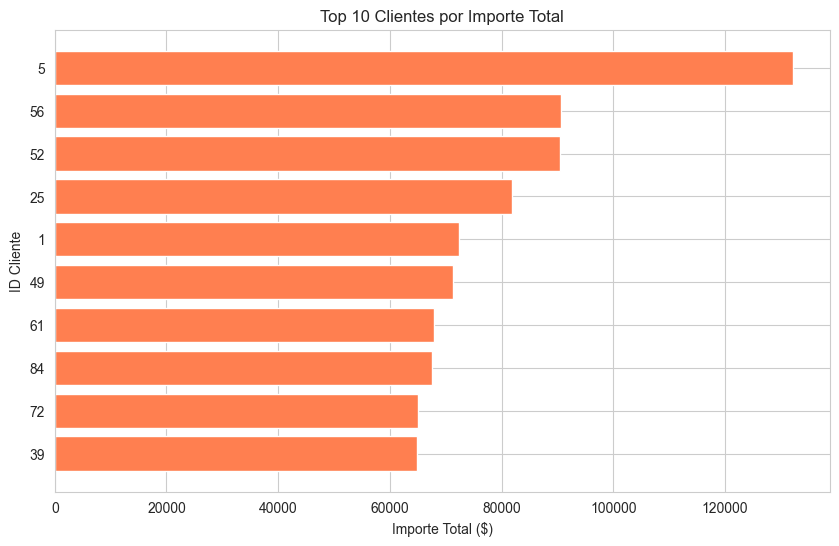

In [20]:
# Top 10 clientes por importe total
top10_clientes = ventas_cliente.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10_clientes.index.astype(str), top10_clientes['importe_total'], color='coral')
plt.xlabel('Importe Total ($)')
plt.ylabel('ID Cliente')
plt.title('Top 10 Clientes por Importe Total')
plt.gca().invert_yaxis()
plt.show()

In [21]:
# Calcular días desde la última compra (recency)
fecha_analisis = pd.Timestamp('2025-01-06')  # Fecha actual o de análisis
ventas_cliente['dias_desde_ultima'] = (fecha_analisis - ventas_cliente['ultima_compra']).dt.days
ventas_cliente.head(10)

,importe_total,importe_promedio,num_compras,primera_compra,ultima_compra,dias_desde_ultima
id_cliente,,,,,,
5,132158,8810.533333,15,2024-03-05,2024-06-25,195
56,90701,9070.100000,10,2024-01-25,2024-06-27,193
52,90522,8229.272727,11,2024-05-04,2024-05-28,223
25,81830,9092.222222,9,2024-03-18,2024-06-19,201
1,72448,8049.777778,9,2024-02-06,2024-03-26,286
49,71321,5486.230769,13,2024-01-23,2024-03-17,295
61,67959,13591.800000,5,2024-05-23,2024-05-30,221
84,67575,8446.875000,8,2024-01-26,2024-02-09,332
72,65001,10833.500000,6,2024-01-02,2024-04-21,260


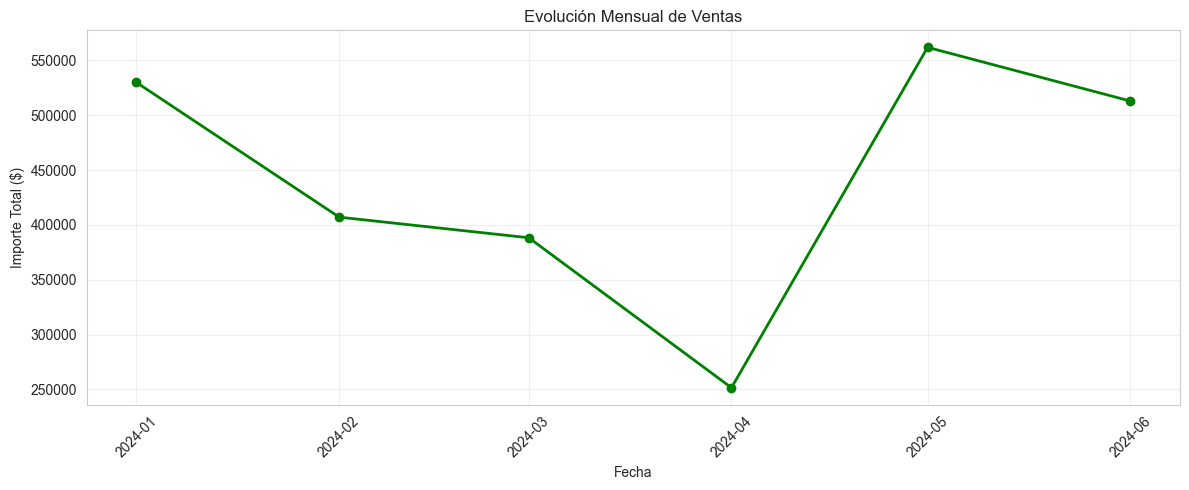

In [22]:
# Evolución temporal de ventas
ventas_temporal = df.groupby(df['fecha'].dt.to_period('M'))['importe'].sum()
ventas_temporal.index = ventas_temporal.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(ventas_temporal.index, ventas_temporal.values, marker='o', linestyle='-', color='green', linewidth=2)
plt.title('Evolución Mensual de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Importe Total ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

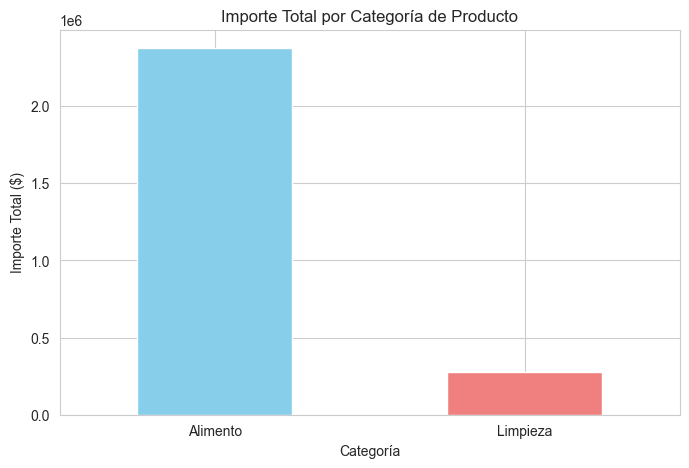

In [23]:
# Ventas por categoría de producto
ventas_categoria = df.groupby('categoria')['importe'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
ventas_categoria.plot.bar(color=['skyblue', 'lightcoral'])
plt.title('Importe Total por Categoría de Producto')
plt.xlabel('Categoría')
plt.ylabel('Importe Total ($)')
plt.xticks(rotation=0)
plt.show()

### 3.4 Gráficos de Verificación
Análisis complementario para validar insights

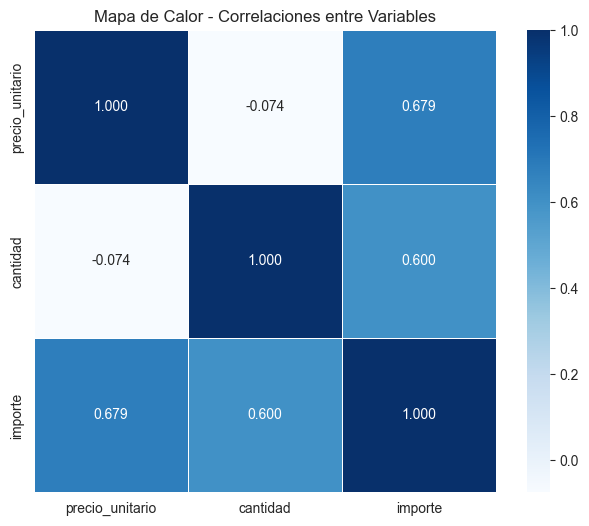

In [24]:
# Heatmap de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5, square=True)
plt.title('Mapa de Calor - Correlaciones entre Variables')
plt.show()

### 3.3 Correlaciones / Mapa de Calor
Análisis de correlaciones entre variables numéricas

In [25]:
# Estadísticas del importe
df['importe'].describe()

count      343.000000
mean      7730.078717
std       5265.543077
min        272.000000
25%       3489.000000
50%       6702.000000
75%      10231.500000
max      24865.000000
Name: importe, dtype: float64